In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [55]:
train = pd.read_csv(r"C:\Users\revat\Downloads\archive (16)\train.csv")
store = pd.read_csv(r"C:\Users\revat\Downloads\archive (16)\store.csv")

C:\Users\revat\AppData\Local\Temp\ipykernel_18928\552933913.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r"C:\Users\revat\Downloads\archive (16)\train.csv")


In [56]:
df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,0.0,0.0,0
1112,1113,a,c,9260.0,0.0,0.0,0,0.0,0.0,0
1113,1114,a,c,870.0,0.0,0.0,0,0.0,0.0,0


In [57]:
df.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [58]:
df.tail(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,0.0,0.0,0
1112,1113,a,c,9260.0,0.0,0.0,0,0.0,0.0,0
1113,1114,a,c,870.0,0.0,0.0,0,0.0,0.0,0
1114,1115,d,c,5350.0,0.0,0.0,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [59]:
df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000
mean,558.00000,5390.358744,4.930942,1370.939013,0.512108,12.083408,1030.239462
std,322.01708,7657.973705,4.284924,935.467654,0.500078,15.542241,1006.038782
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,279.50000,710.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,558.00000,2320.000000,4.000000,2006.000000,1.000000,1.000000,2009.000000
75%,836.50000,6875.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [60]:
df.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [61]:
df.columns.tolist()

['Store',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval']

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            1115 non-null   float64
 8   Promo2SinceYear            1115 non-null   float64
 9   PromoInterval              1115 non-null   object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [63]:
df.sample(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
599,600,d,c,17340.0,6.0,2010.0,1,9.0,2011.0,"Feb,May,Aug,Nov"
371,372,d,c,4880.0,8.0,2010.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct"
837,838,d,c,6890.0,0.0,0.0,1,48.0,2011.0,"Mar,Jun,Sept,Dec"
512,513,a,a,400.0,8.0,2013.0,0,0.0,0.0,0
673,674,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov"


In [64]:
df.shape

(1115, 10)

In [65]:
df.dtypes

Store                          int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [66]:
df.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [67]:
df.duplicated().sum()

0

In [68]:
df.fillna(0,inplace=True)

In [70]:
df = pd.merge(train, store, on="Store", how="left")

In [72]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [73]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [74]:
df.columns


Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [79]:
print(df["StateHoliday"].unique())
print(df["StateHoliday"].dtype)

[0 1 2 3]
int32


In [99]:
le = LabelEncoder()

df["StoreType"] = le.fit_transform(df["StoreType"])
df["Assortment"] = le.fit_transform(df["Assortment"])
df["StateHoliday"] = le.fit_transform(df["StateHoliday"])
df["PromoInterval"] = le.fit_transform(df["PromoInterval"].astype(str))

In [103]:
df.columns.tolist()

['Store',
 'DayOfWeek',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'Year',
 'Month',
 'Day']

In [112]:
print(train.columns.tolist())
print(store.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [113]:
df = pd.merge(train, store, on="Store", how="left")

In [114]:
print(df.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [116]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [117]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)

df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

df["PromoInterval"] = df["PromoInterval"].fillna("None")

In [118]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["StoreType"] = le.fit_transform(df["StoreType"].astype(str))
df["Assortment"] = le.fit_transform(df["Assortment"].astype(str))
df["StateHoliday"] = le.fit_transform(df["StateHoliday"].astype(str))
df["PromoInterval"] = le.fit_transform(df["PromoInterval"].astype(str))

In [119]:
X = df[
[
    "DayOfWeek",
    "Customers",
    "Promo",
    "SchoolHoliday",
    "StateHoliday",
    "StoreType",
    "CompetitionDistance",
    "Promo2",
    "PromoInterval",
    "Month",
    "Year"
]]

y = df["Sales"]

In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [123]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [125]:
y_pred = lr.predict(X_test)

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 985.5445377462061
MSE : 2128025.5558857536
RMSE : 1458.7753616941004
R2 Score : 0.8561055591578692


In [127]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
76435,0,313.351629
923026,5548,6739.096578
731180,7467,8087.530762
790350,3360,4237.151807
252134,11414,8965.626363
425310,0,181.116630
666826,14126,8408.261867
881992,6299,6417.947255
783899,10515,11458.470686
540518,7713,8259.993989


In [134]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [135]:
xgb_pred = xgb.predict(X_test)

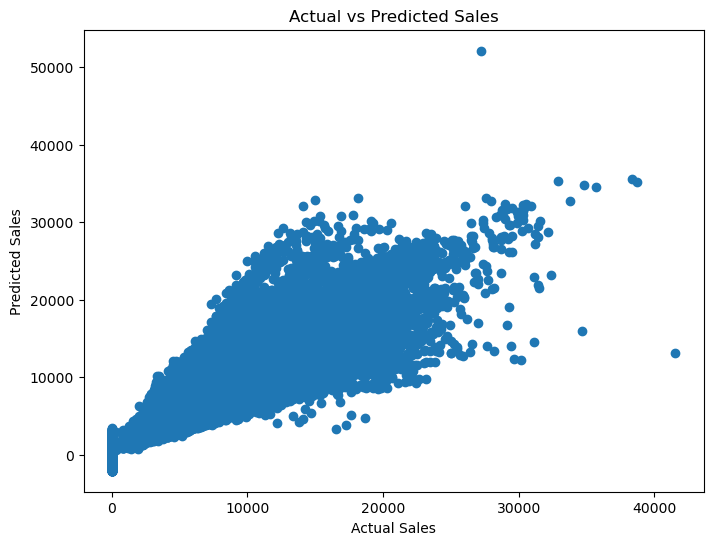

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [137]:
df["Promo"].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

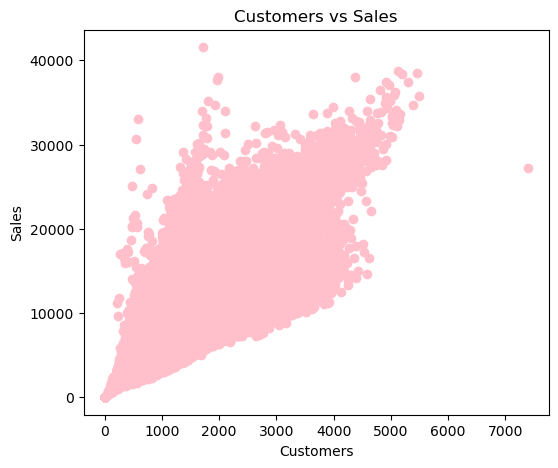

In [140]:
plt.figure(figsize=(6,5))
plt.scatter(df["Customers"], df["Sales"], color="pink")

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

In [141]:
X["Promo"]

0          1
1          1
2          1
3          1
4          1
          ..
1017204    0
1017205    0
1017206    0
1017207    0
1017208    0
Name: Promo, Length: 1017209, dtype: int64

In [143]:
df["StateHoliday"].value_counts()
df["SchoolHoliday"].value_counts()

SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

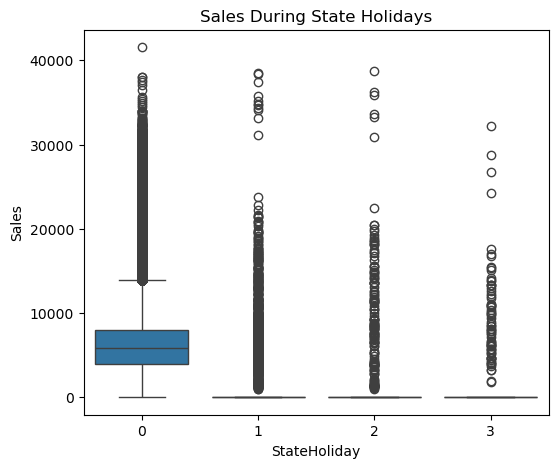

In [146]:
plt.figure(figsize=(6,5))
sns.boxplot(x="StateHoliday", y="Sales", data=df)
plt.title("Sales During State Holidays")
plt.show()

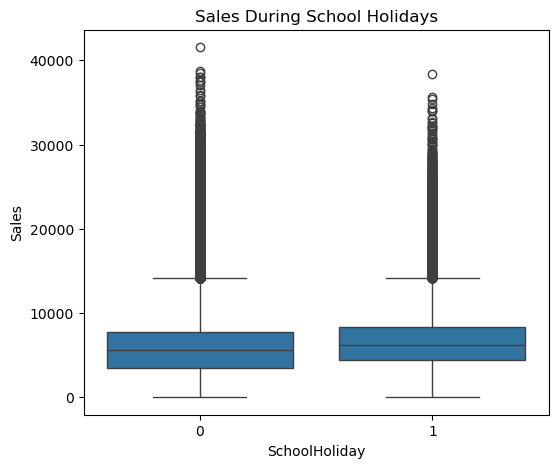

In [147]:
plt.figure(figsize=(6,5))
sns.boxplot(x="SchoolHoliday", y="Sales", data=df)
plt.title("Sales During School Holidays")
plt.show()

In [148]:
df["StoreType"].value_counts()

StoreType
0    551627
3    312912
2    136840
1     15830
Name: count, dtype: int64

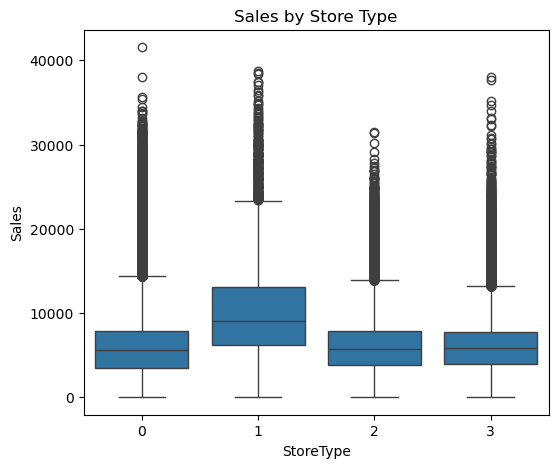

In [149]:
plt.figure(figsize=(6,5))
sns.boxplot(x="StoreType", y="Sales", data=df)
plt.title("Sales by Store Type")
plt.show()

Text(0.5, 1.0, 'Customers vs Sales')

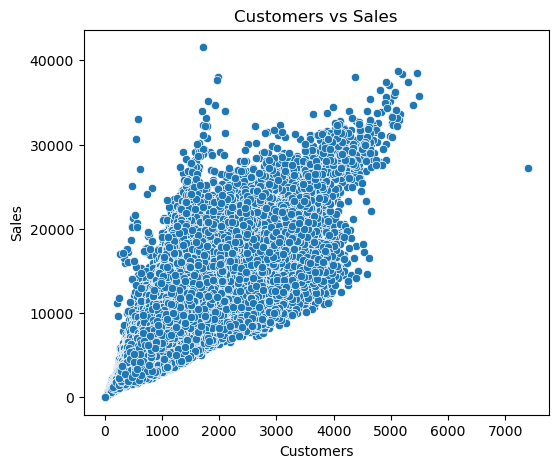

In [150]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Customers",
    y="Sales",
    data=df
)
plt.title("Customers vs Sales")


Text(0.5, 1.0, 'Competition Distance vs Sales')

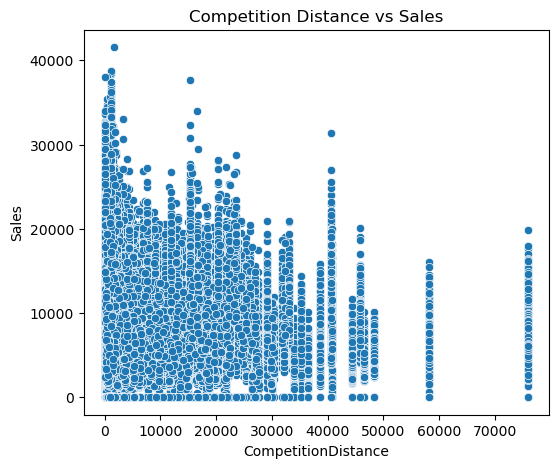

In [151]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="CompetitionDistance",
    y="Sales",
    data=df
)
plt.title("Competition Distance vs Sales")


Text(0.5, 1.0, 'Sales by Day of Week')

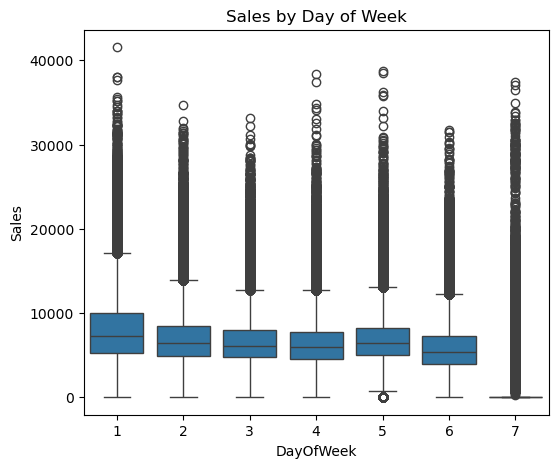

In [152]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="DayOfWeek",
    y="Sales",
    data=df
)
plt.title("Sales by Day of Week")


In [153]:
X = df[[
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "StoreType",
    "Customers",
    "CompetitionDistance",
    "DayOfWeek",
    "Promo2",
    "Month",
    "Year"
]]

y = df["Sales"]

In [156]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [157]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

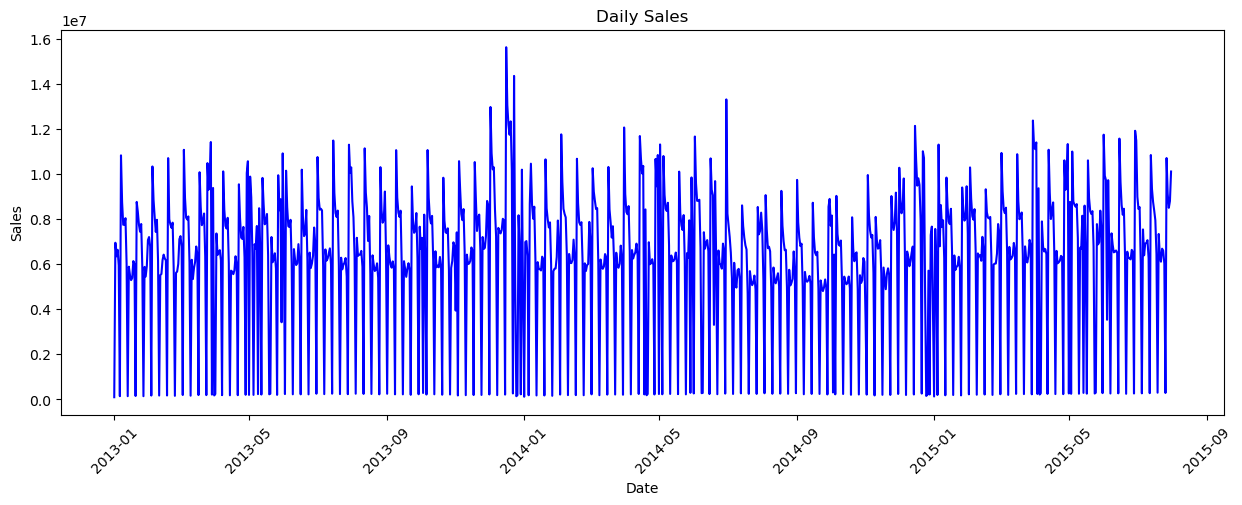

In [160]:
daily_sales = df.groupby("Date")["Sales"].sum().reset_index()

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    color="blue"
)

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

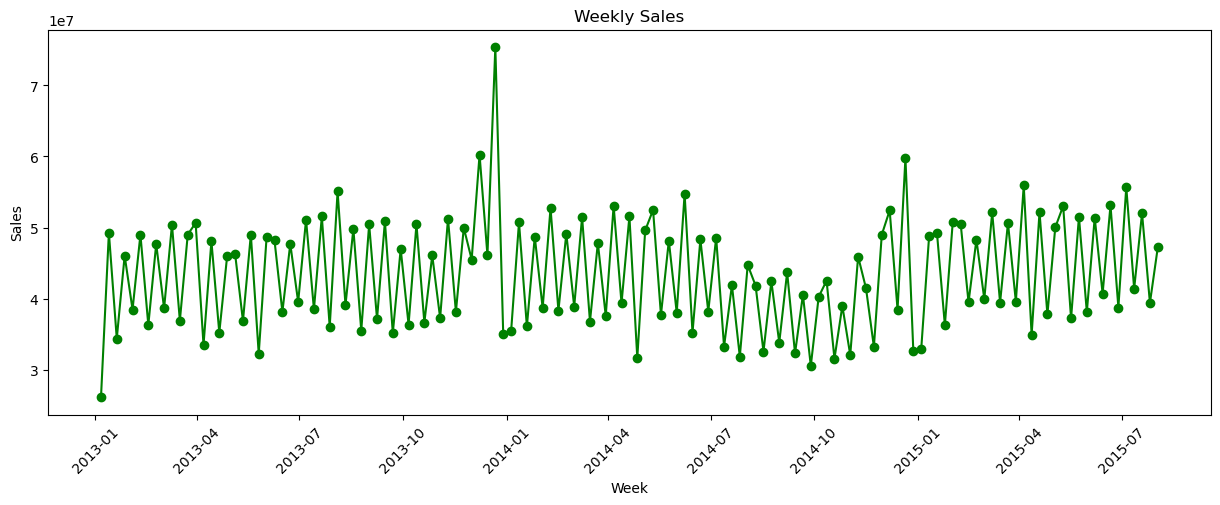

In [161]:
weekly_sales = df.groupby(
    pd.Grouper(key="Date", freq="W")
)["Sales"].sum().reset_index()

plt.figure(figsize=(15,5))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    color="green",
    marker="o"
)

plt.title("Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

C:\Users\revat\AppData\Local\Temp\ipykernel_18928\3120878669.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Date", freq="M")


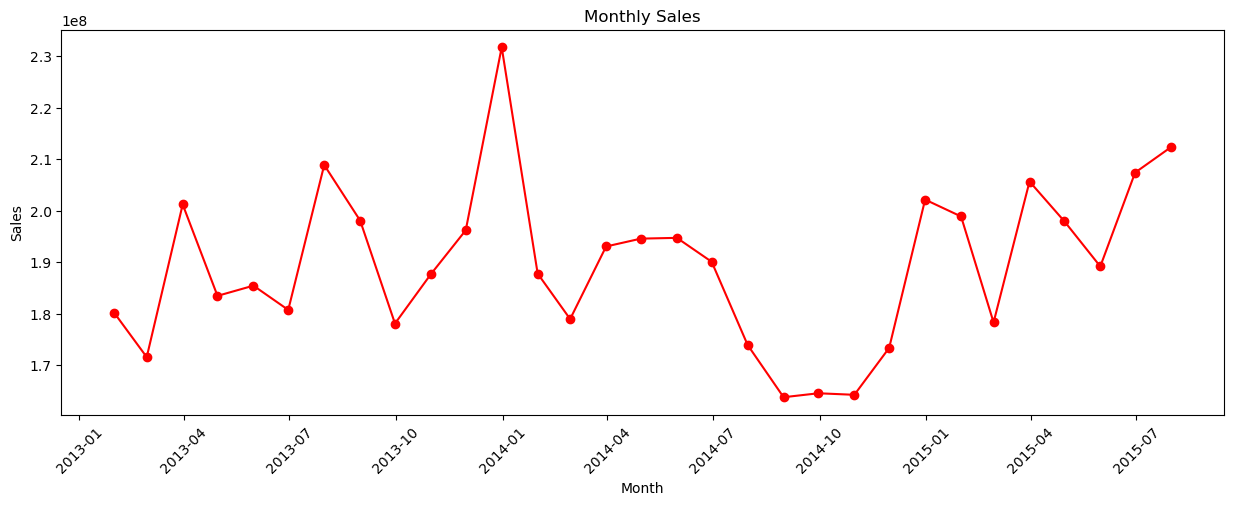

In [162]:
monthly_sales = df.groupby(
    pd.Grouper(key="Date", freq="M")
)["Sales"].sum().reset_index()

plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    color="red",
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

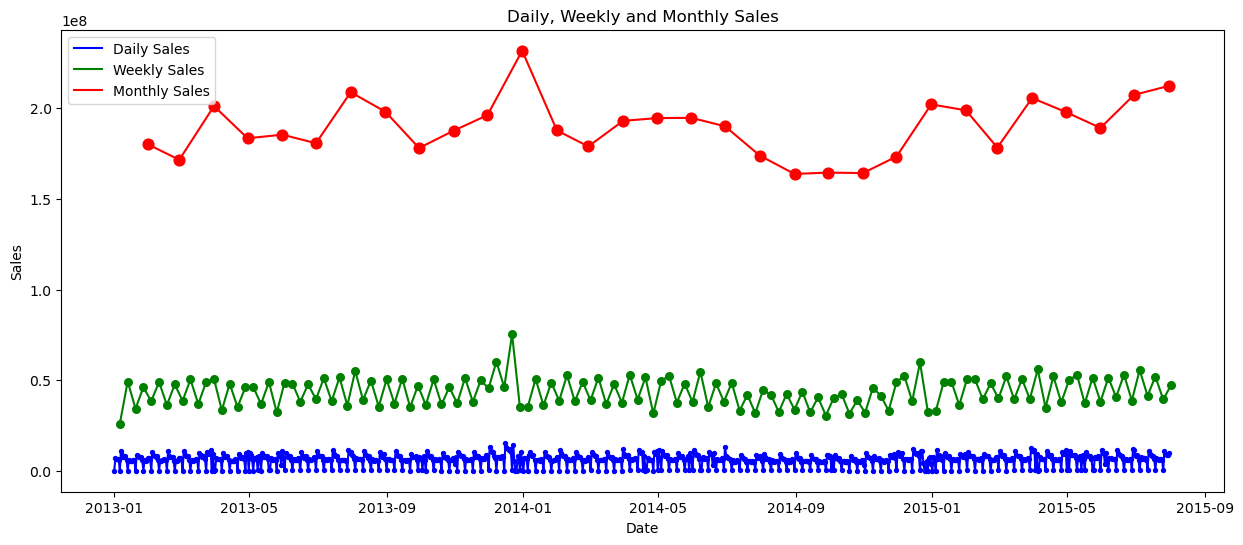

In [165]:
import matplotlib.pyplot as plt
import pandas as pd

# Daily Sales
daily = df.groupby("Date")["Sales"].sum()

# Weekly Sales
weekly = df.groupby(pd.Grouper(key="Date", freq="W"))["Sales"].sum()

# Monthly Sales
monthly = df.groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].sum()

plt.figure(figsize=(15,6))

plt.plot(daily.index, daily.values, label="Daily Sales", color="blue")

plt.plot(weekly.index, weekly.values, label="Weekly Sales", color="green")

plt.plot(monthly.index, monthly.values, label="Monthly Sales", color="red")

plt.scatter(daily.index, daily.values, color="blue", s=8)

plt.scatter(weekly.index, weekly.values, color="green", s=30)

plt.scatter(monthly.index, monthly.values, color="red", s=60)

plt.title("Daily, Weekly and Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
